# Forest management

## Foreword

## 1. Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl
import seaborn as sns
from inventory_data import load_inventory

## 2. Data import

In [2]:
df = load_inventory()

## 3. Diameter distribution status

In [3]:
# Select all rows with Scientific name == 'Prioria copaifera' or 'Brosimum utile'
species_df = df[df['Scientific name'].isin(['Prioria copaifera', 'Brosimum utile'])].copy()

print(f"Total prior species' trees: {len(species_df)}")
species_df.info()

Total prior species' trees: 896
<class 'pandas.core.frame.DataFrame'>
Index: 896 entries, 11 to 11984
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Line Number            896 non-null    category
 1   Plot                   896 non-null    category
 2   Subplot                896 non-null    category
 3   Tree number            896 non-null    category
 4   Tree name              896 non-null    category
 5   Scientific name        896 non-null    category
 6   Commercial group       896 non-null    category
 7   DBH [cm]               896 non-null    float64 
 8   DBH [m]                896 non-null    float64 
 9   Commercial height [m]  896 non-null    float64 
 10  Stem quality           896 non-null    category
 11  Observations           29 non-null     object  
 12  Basal area [m2]        896 non-null    float64 
 13  Volume [m3]            896 non-null    float64 
 14  DBH Class   

In [4]:
#The of each line in hectares
plot_size = 5000
plot_size_ha = plot_size/10000

print(f'The area of sample plots is: {plot_size} m², which means {plot_size_ha} ha.')

# counts per line
plot_counts = df.groupby('Line Number')['Plot'].nunique().sort_index()
print(plot_counts)

line_area_df = plot_counts.rename('plot_count').to_frame().assign(line_area_ha=lambda x: x['plot_count'] * plot_size_ha)
print(line_area_df)

The area of sample plots is: 5000 m², which means 0.5 ha.
Line Number
1    12
2    19
3    18
4     7
5    10
6    12
7    11
Name: Plot, dtype: int64
             plot_count  line_area_ha
Line Number                          
1                    12           6.0
2                    19           9.5
3                    18           9.0
4                     7           3.5
5                    10           5.0
6                    12           6.0
7                    11           5.5


C:\Users\migue\AppData\Local\Temp\ipykernel_13512\3259818346.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_counts = df.groupby('Line Number')['Plot'].nunique().sort_index()


### 3.1 Diameter distribution

C:\Users\migue\AppData\Local\Temp\ipykernel_13512\2222341575.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = line_data.groupby(["DBH Class", "Scientific name"]).size().unstack(fill_value=0)
C:\Users\migue\AppData\Local\Temp\ipykernel_13512\2222341575.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = line_data.groupby(["DBH Class", "Scientific name"]).size().unstack(fill_value=0)
C:\Users\migue\AppData\Local\Temp\ipykernel_13512\2222341575.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to

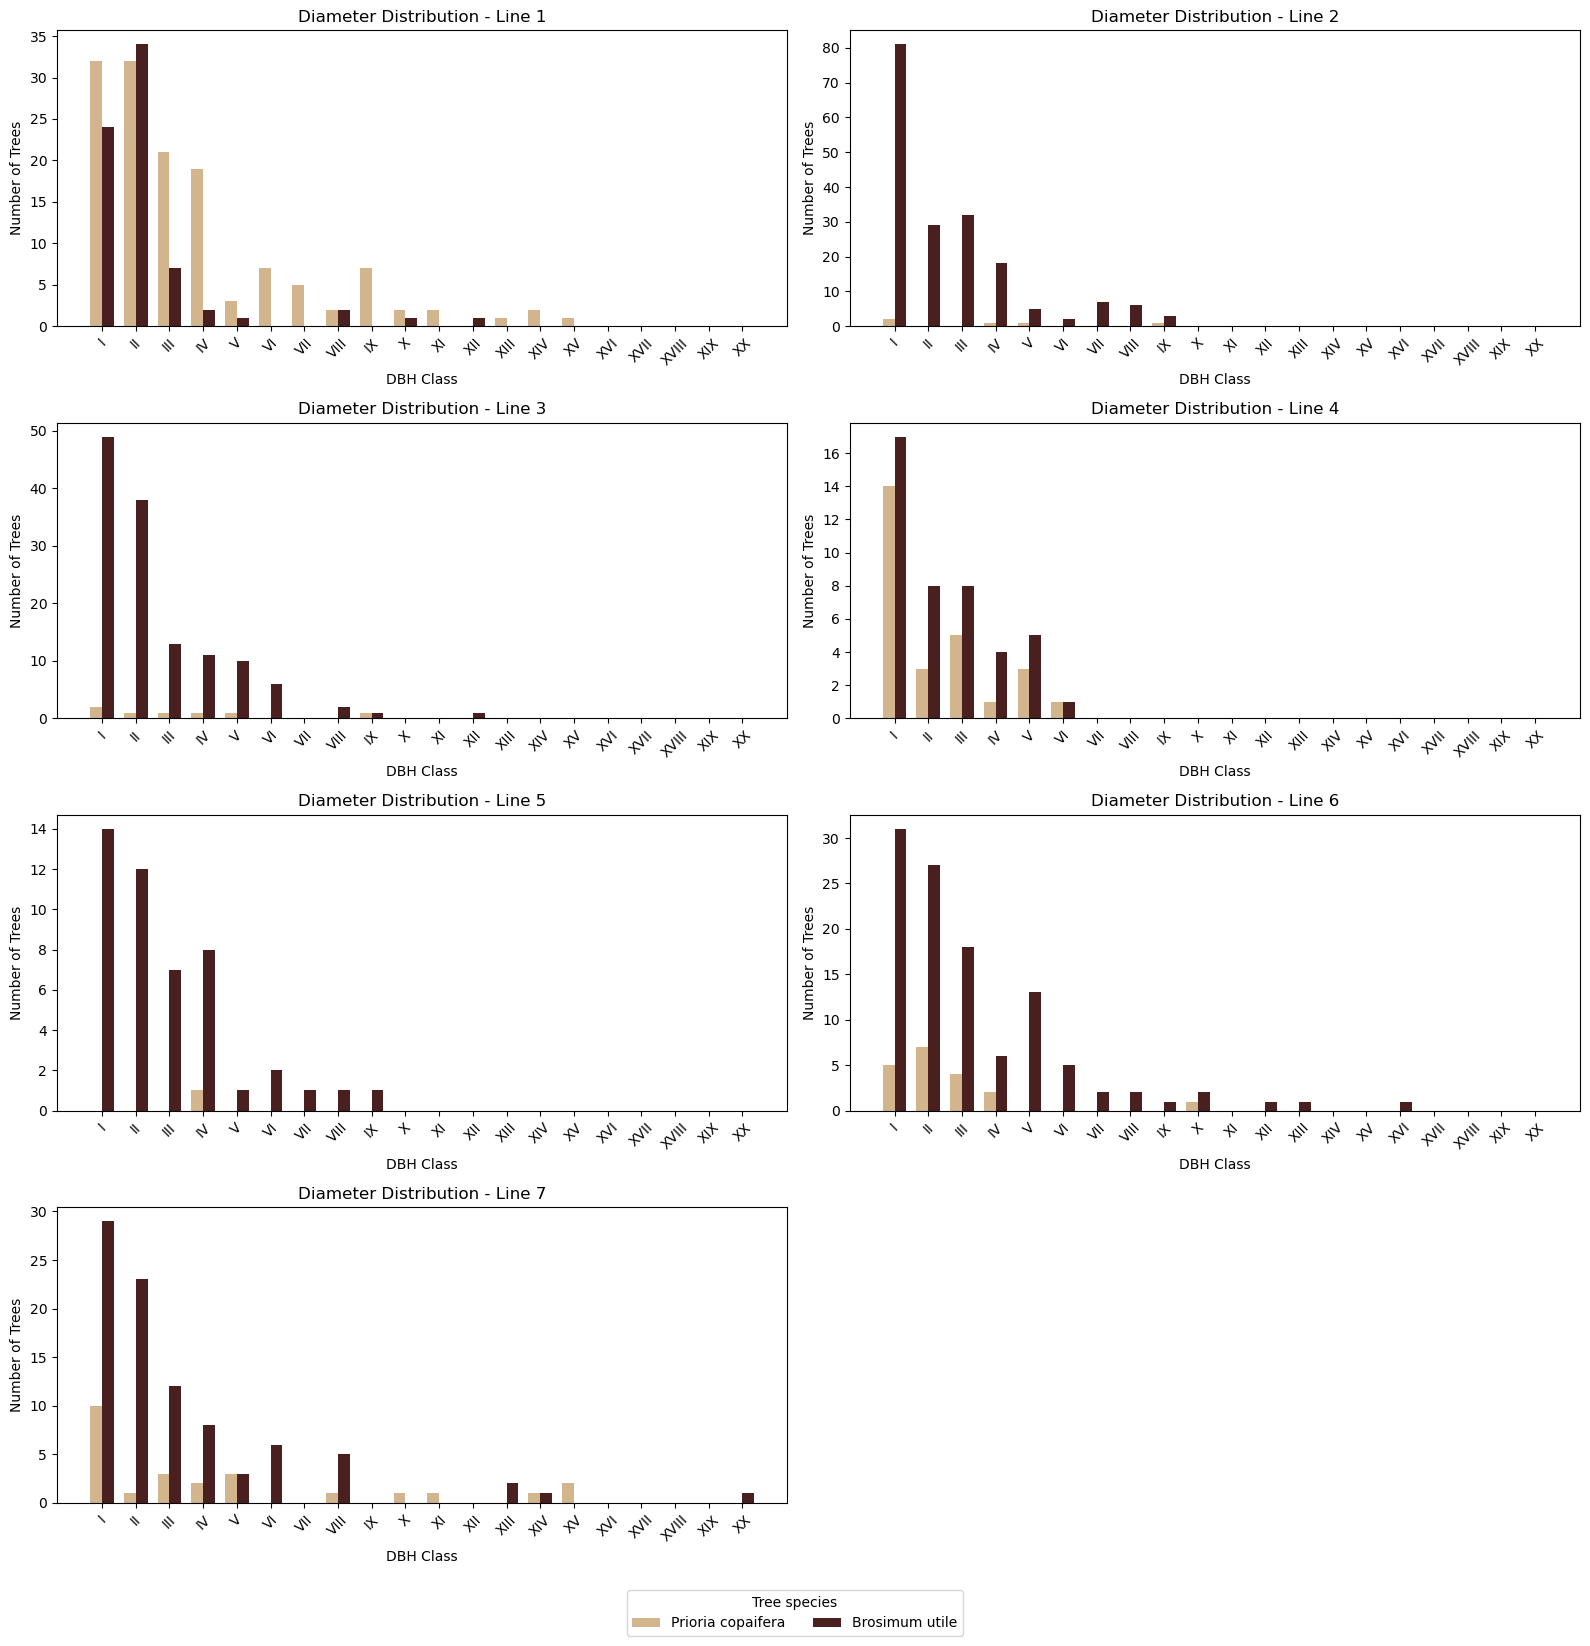

In [5]:
# Define color mapping and species order
species_order = ['Prioria copaifera', 'Brosimum utile']
color_map = {
    'Brosimum utile': "#491f1f",
    'Prioria copaifera': "#D3B58D"
}

# Create a 4x2 matrix of subplots, one for each line number, with side-by-side bars per species
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

# determine ordered DBH Class categories
if hasattr(species_df["DBH Class"], "cat"):
    dbh_categories = list(species_df["DBH Class"].cat.categories)
else:
    dbh_categories = sorted(species_df["DBH Class"].unique())

width = 0.35

for i, line_num in enumerate(range(1, 8)):
    line_data = species_df.loc[species_df["Line Number"] == line_num]
    # counts per DBH Class and Scientific name
    counts = line_data.groupby(["DBH Class", "Scientific name"]).size().unstack(fill_value=0)

    # ensure both species are present in the columns and in the specified order
    for s in species_order:
        if s not in counts.columns:
            counts[s] = 0
    counts = counts[species_order]

    # ensure all DBH categories are present
    counts = counts.reindex(index=dbh_categories, fill_value=0)

    x = np.arange(len(counts))

    for j, species in enumerate(species_order):
        offsets = (j - (len(species_order) - 1)/2) * width
        axes[i].bar(x + offsets, counts[species].values, width, label=species if i == 0 else "", color=color_map.get(species))

    axes[i].set_xlabel('DBH Class')
    axes[i].set_ylabel('Number of Trees')
    axes[i].set_title(f'Diameter Distribution - Line {line_num}')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(counts.index, rotation=45)

# Place a single horizontal legend centered below all subplots with a title
legend = fig.legend(ncol=len(species_order), loc='lower center', bbox_to_anchor=(0.5, -0.03), frameon=True, title='Tree species')
legend.get_title().set_fontsize('medium')
try:
    legend._legend_box.align = "center"
except Exception:
    pass

# Hide the last empty subplot
axes[7].set_visible(False)

# Adjust layout to make room for the legend (reduced bottom space)
plt.tight_layout(rect=[0, 0.01, 1, 1])
plt.show()


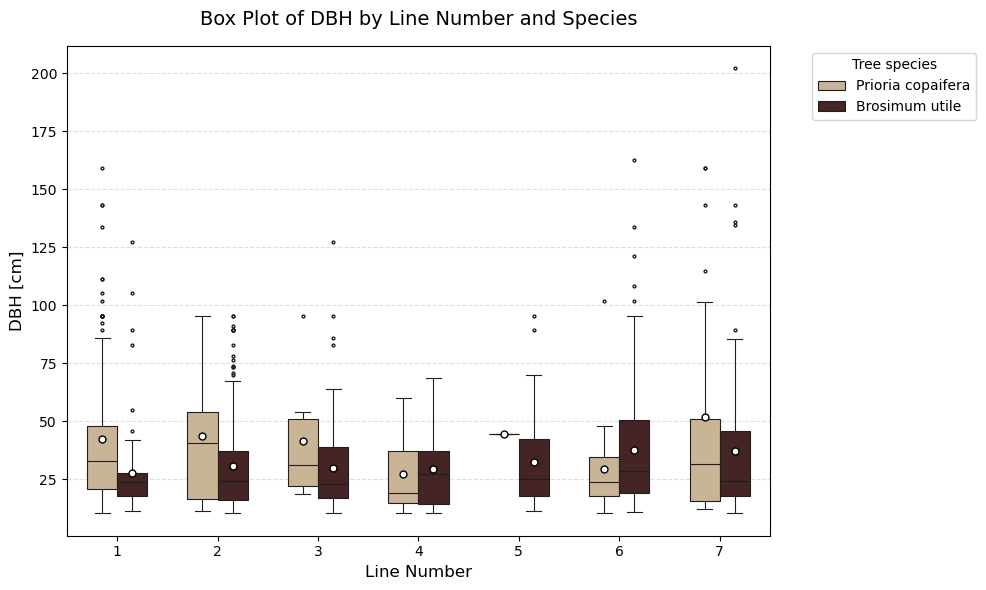

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter the data to include ONLY the two target species
# This ensures the legend doesn't pick up extra species
filtered_plot_df = species_df[species_df['Scientific name'].isin(species_order)].copy()

# 2. Convert Line Number to integer for clean X-axis labels (no .0)
filtered_plot_df['Line Number'] = filtered_plot_df['Line Number'].astype(int)

# Define mapping and order
species_order = ['Prioria copaifera', 'Brosimum utile']
color_map = {
    'Brosimum utile': "#491f1f",
    'Prioria copaifera': "#D3B58D"
}

plt.figure(figsize=(10, 6))

# 3. Create the plot using the filtered data
sns.boxplot(
    x="Line Number",
    y="DBH [cm]",
    hue="Scientific name",
    hue_order=species_order, # Explicitly set legend order
    data = species_df,
    palette=[color_map[s] for s in species_order],
    width=0.6,
    linewidth=0.8,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"5"},
    fliersize=2
)

plt.title("Box Plot of DBH by Line Number and Species", fontsize=14, pad=15)
plt.xlabel("Line Number", fontsize=12)
plt.ylabel("DBH [cm]", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Optional: Place legend outside if it overlaps data
plt.legend(title="Tree species", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

C:\Users\migue\AppData\Local\Temp\ipykernel_13512\1212168490.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_counts = df.groupby('Line Number')['Plot'].nunique()
C:\Users\migue\AppData\Local\Temp\ipykernel_13512\1212168490.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = line_data.groupby(["DBH Class", "Scientific name"]).size().unstack(fill_value=0)
C:\Users\migue\AppData\Local\Temp\ipykernel_13512\1212168490.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or obse

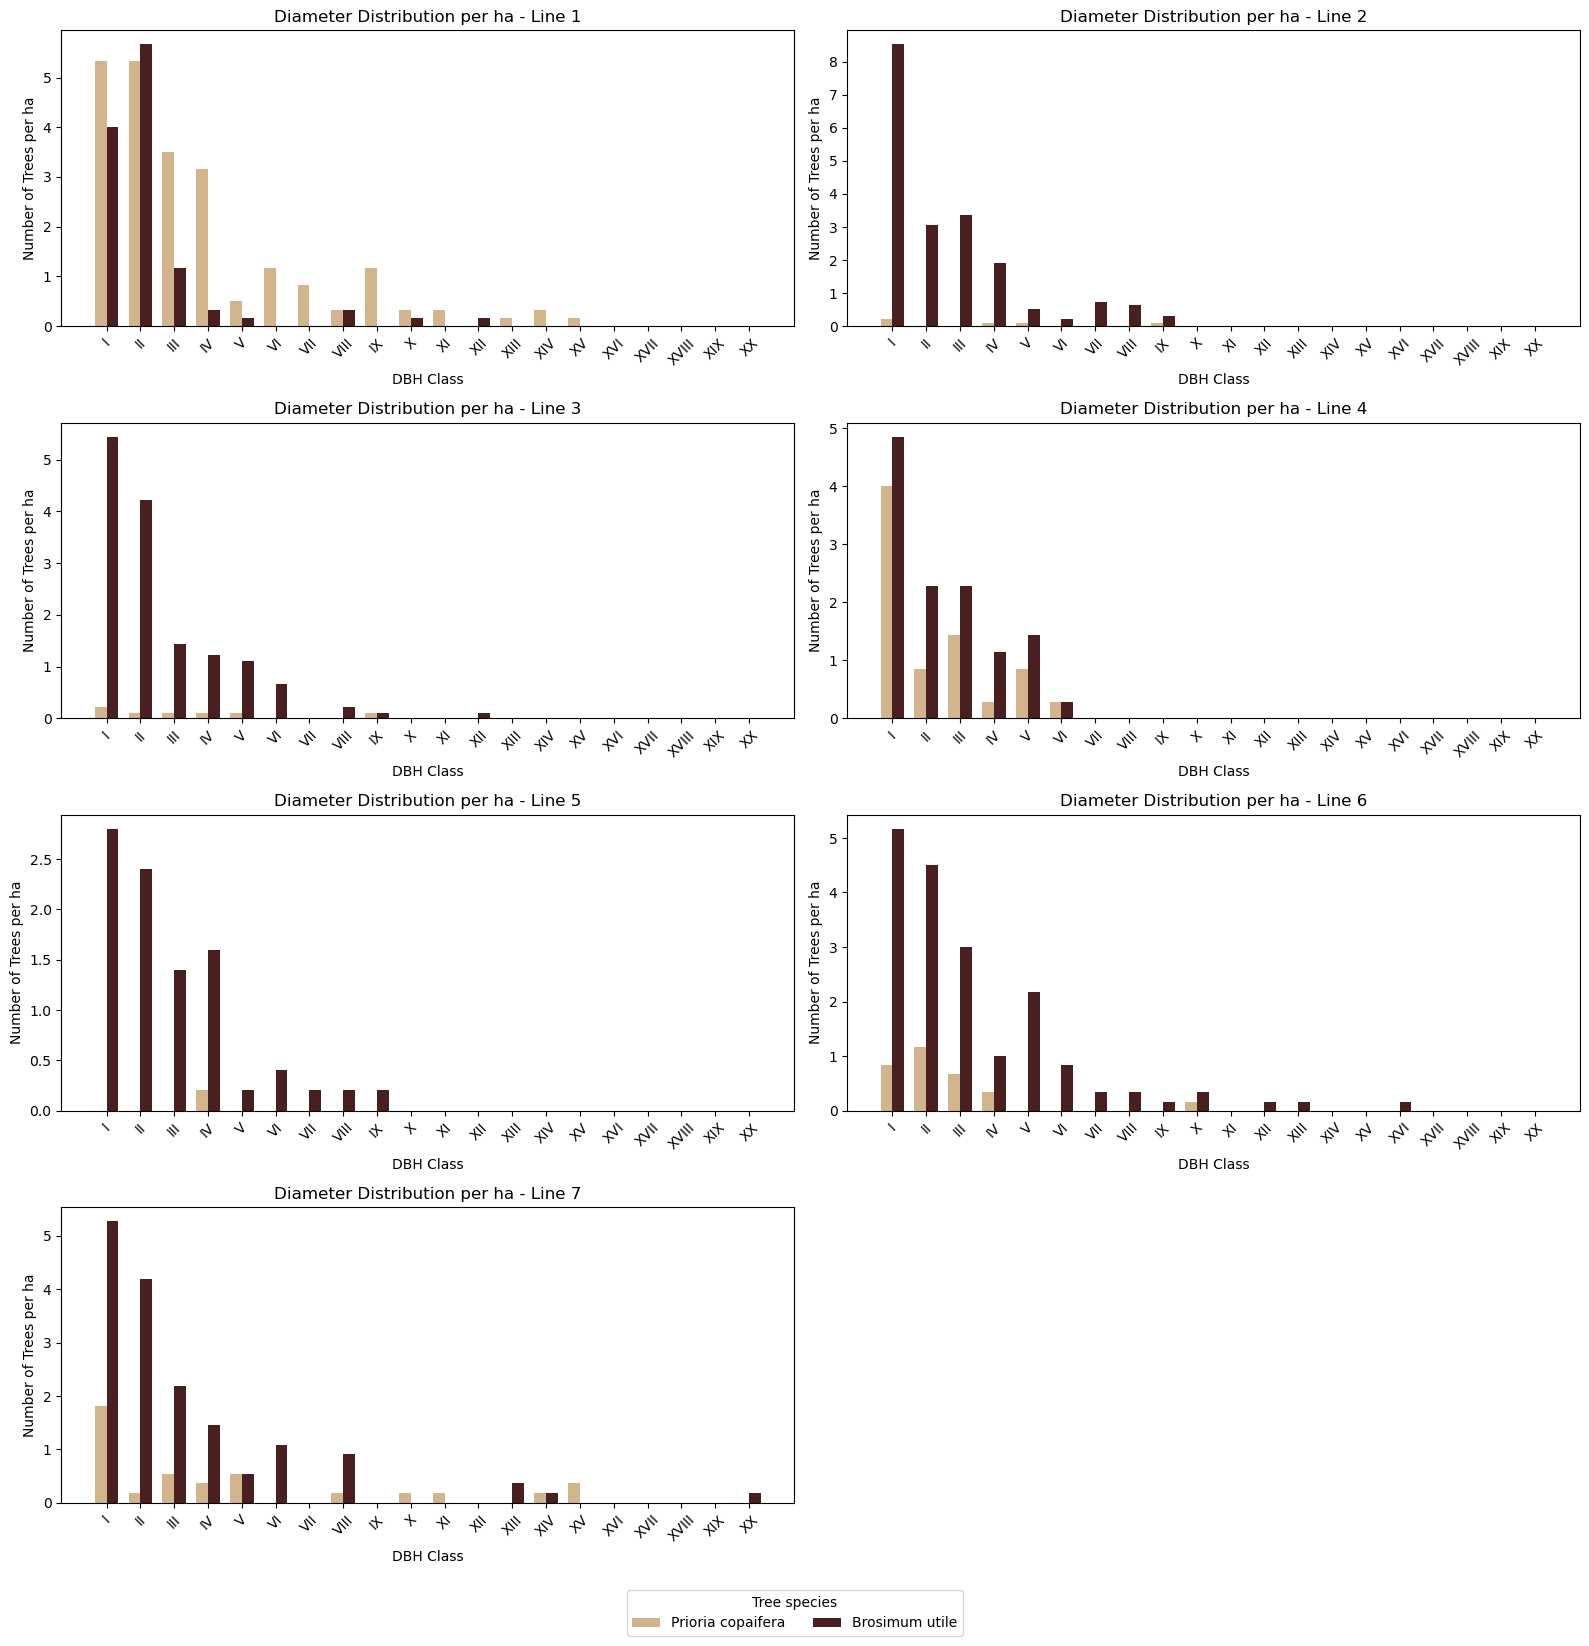

In [7]:
# Create a 4x2 matrix of subplots, one for each line number
# Side-by-side bars per species showing counts per hectare
species_order = ['Prioria copaifera', 'Brosimum utile']
color_map = {
    'Brosimum utile': "#491f1f",
    'Prioria copaifera': "#D3B58D"
}

fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

# Ensure plot area and counts exist; fall back to defaults if not
try:
    plot_size_ha
except NameError:
    plot_size = 5000
    plot_size_ha = plot_size / 10000

plot_counts = df.groupby('Line Number')['Plot'].nunique()
line_area_ha = plot_counts * plot_size_ha

# determine ordered DBH Class categories
if hasattr(species_df["DBH Class"], "cat"):
    dbh_categories = list(species_df["DBH Class"].cat.categories)
else:
    dbh_categories = sorted(species_df["DBH Class"].unique())

width = 0.35

for i, line_num in enumerate(range(1, 8)):
    line_data = species_df[species_df["Line Number"] == line_num]

    # counts per DBH Class and Scientific name
    counts = line_data.groupby(["DBH Class", "Scientific name"]).size().unstack(fill_value=0)

    # ensure both species are present and in order
    for s in species_order:
        if s not in counts.columns:
            counts[s] = 0
    counts = counts[species_order]

    # ensure all DBH categories are present
    counts = counts.reindex(index=dbh_categories, fill_value=0)

    # compute per-hectare values
    area = line_area_ha.get(line_num, np.nan)
    if area and area > 0:
        counts_per_ha = counts / area
    else:
        counts_per_ha = counts.copy() * np.nan

    x = np.arange(len(counts_per_ha))

    for j, species in enumerate(species_order):
        offsets = (j - (len(species_order) - 1)/2) * width
        axes[i].bar(x + offsets, counts_per_ha[species].values, width, label=species if i == 0 else "", color=color_map.get(species))

    axes[i].set_xlabel('DBH Class')
    axes[i].set_ylabel('Number of Trees per ha')
    axes[i].set_title(f'Diameter Distribution per ha - Line {line_num}')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(counts_per_ha.index, rotation=45)

# Place a single horizontal legend centered below all subplots with a title
legend = fig.legend(ncol=len(species_order), loc='lower center', bbox_to_anchor=(0.5, -0.03), frameon=True, title='Tree species')
legend.get_title().set_fontsize('medium')
try:
    legend._legend_box.align = "center"
except Exception:
    pass

# Hide the last empty subplot
axes[7].set_visible(False)

# Adjust layout to make room for the legend
plt.tight_layout(rect=[0, 0.01, 1, 1])
plt.show()


### 3.2 Basal area

C:\Users\migue\AppData\Local\Temp\ipykernel_13512\2880688328.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["DBH Class", "Scientific name"])["Basal area [m2]"].sum()
C:\Users\migue\AppData\Local\Temp\ipykernel_13512\2880688328.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["DBH Class", "Scientific name"])["Basal area [m2]"].sum()
C:\Users\migue\AppData\Local\Temp\ipykernel_13512\2880688328.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to

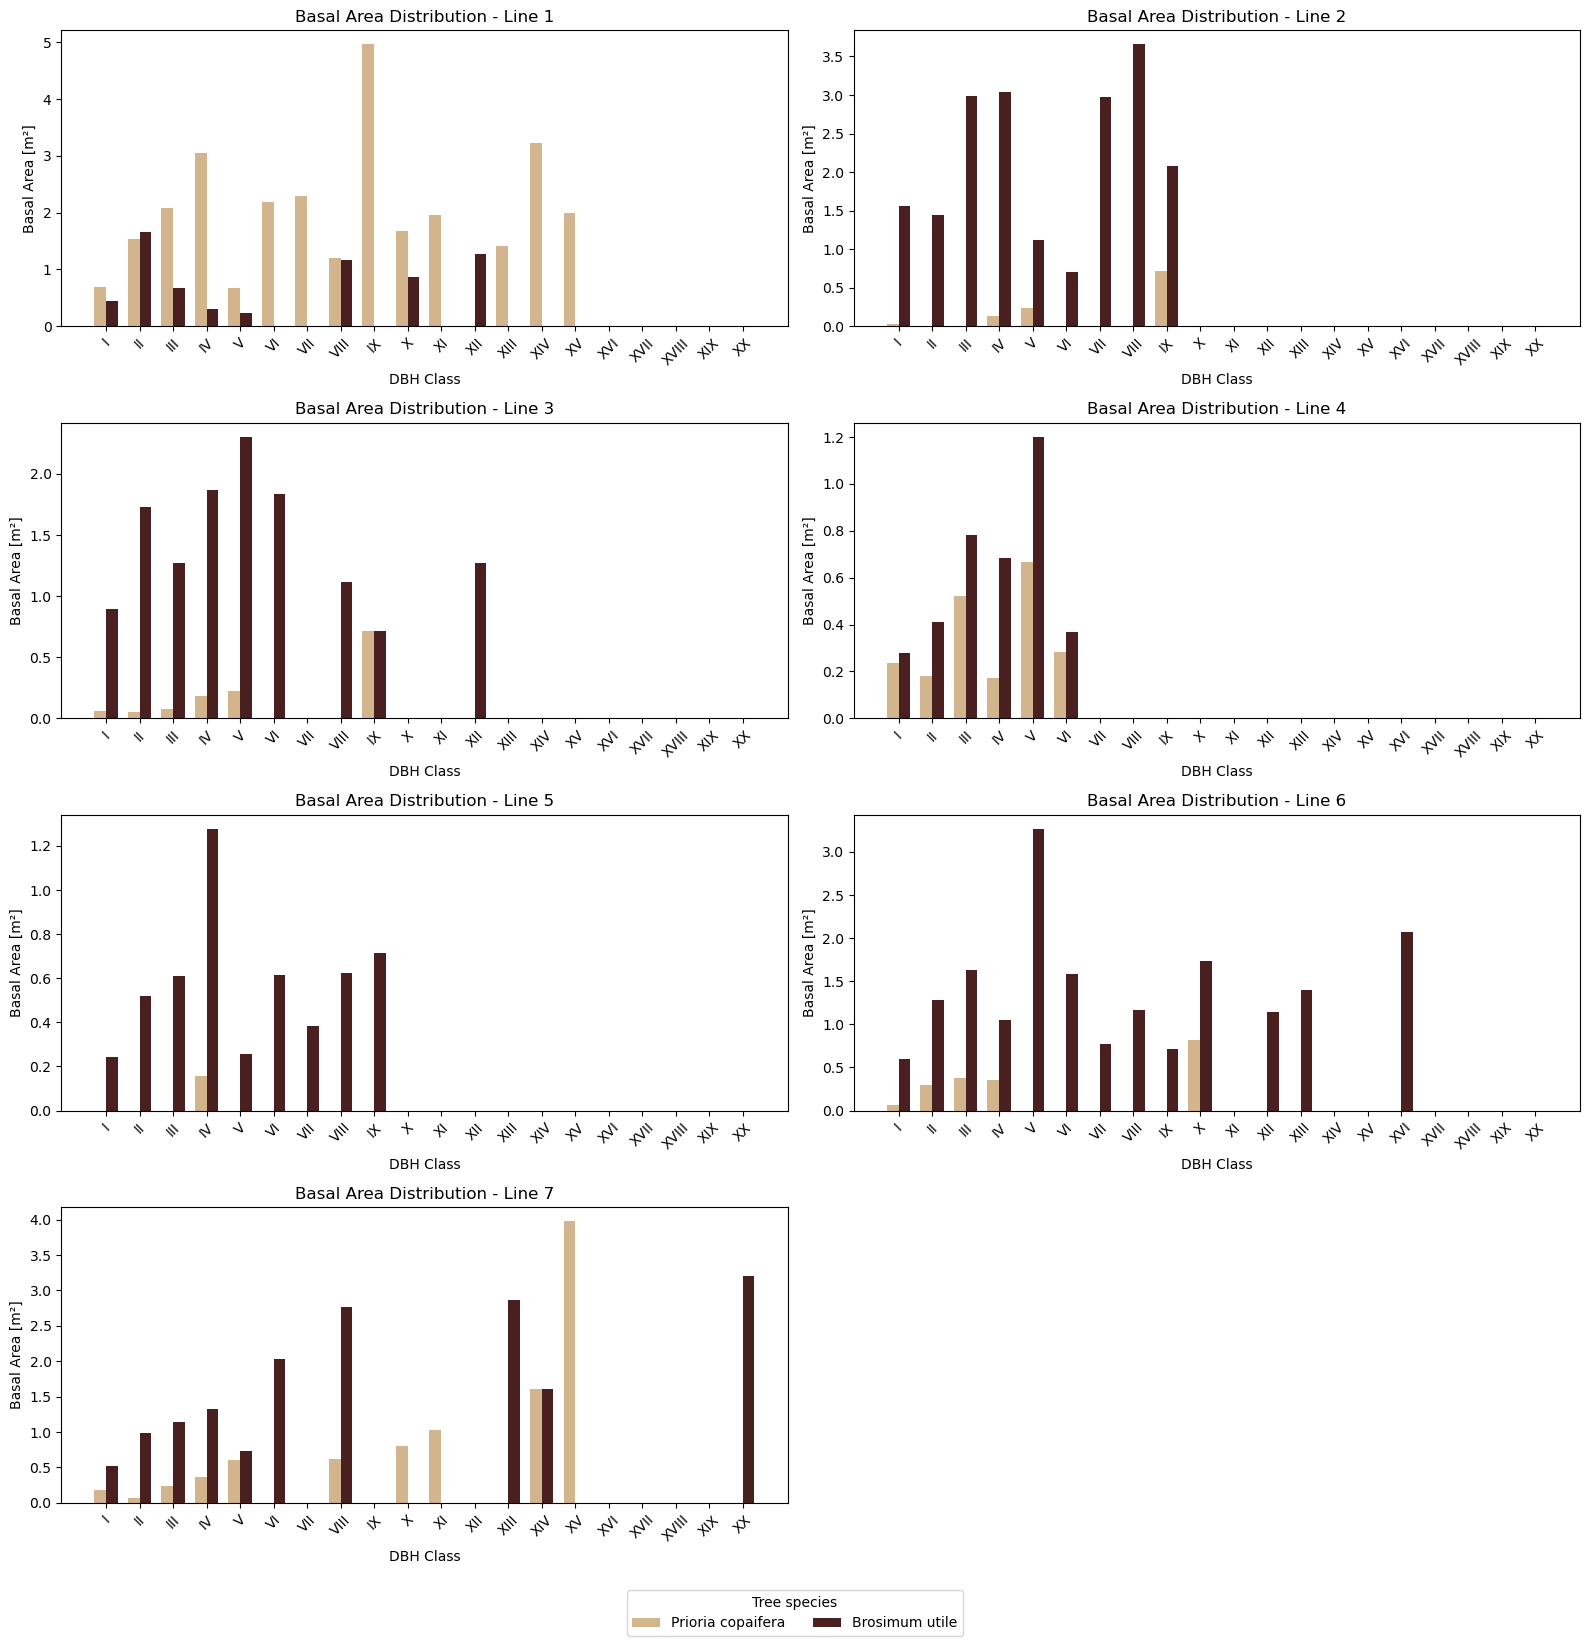

In [8]:
# Side-by-side Basal Area by DBH Class for Prioria copaifera and Brosimum utile
species_order = ['Prioria copaifera', 'Brosimum utile']
color_map = {
    'Brosimum utile': "#491f1f",
    'Prioria copaifera': "#D3B58D"
}

fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

# determine ordered DBH Class categories
if hasattr(species_df["DBH Class"], "cat"):
    dbh_categories = list(species_df["DBH Class"].cat.categories)
else:
    dbh_categories = sorted(species_df["DBH Class"].unique())

width = 0.35

for i, line_num in enumerate(range(1, 8)):
    line_data = species_df.loc[species_df["Line Number"] == line_num]
    # Basal area summed by DBH Class and Scientific name
    ba = (
        line_data
        .groupby(["DBH Class", "Scientific name"])["Basal area [m2]"].sum()
        .unstack(fill_value=0)
    )

    # ensure both species are present in the columns and in the specified order
    for s in species_order:
        if s not in ba.columns:
            ba[s] = 0
    ba = ba[species_order]

    # ensure all DBH categories are present
    ba = ba.reindex(index=dbh_categories, fill_value=0)

    x = np.arange(len(ba))

    for j, species in enumerate(species_order):
        offsets = (j - (len(species_order) - 1)/2) * width
        axes[i].bar(x + offsets, ba[species].values, width, label=species if i == 0 else "", color=color_map.get(species))

    axes[i].set_xlabel('DBH Class')
    axes[i].set_ylabel('Basal Area [m²]')
    axes[i].set_title(f'Basal Area Distribution - Line {line_num}')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(ba.index, rotation=45)

# Place a single horizontal legend centered below all subplots with a title
legend = fig.legend(ncol=len(species_order), loc='lower center', bbox_to_anchor=(0.5, -0.03), frameon=True, title='Tree species')
legend.get_title().set_fontsize('medium')
try:
    legend._legend_box.align = "center"
except Exception:
    pass

# Hide the last empty subplot
axes[7].set_visible(False)

# Adjust layout to make room for the legend (reduced bottom space)
plt.tight_layout(rect=[0, 0.01, 1, 1])
plt.show()


C:\Users\migue\AppData\Local\Temp\ipykernel_13512\1671830651.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_counts = df.groupby('Line Number')['Plot'].nunique()
C:\Users\migue\AppData\Local\Temp\ipykernel_13512\1671830651.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["DBH Class", "Scientific name"])['Basal area [m2]']
C:\Users\migue\AppData\Local\Temp\ipykernel_13512\1671830651.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futur

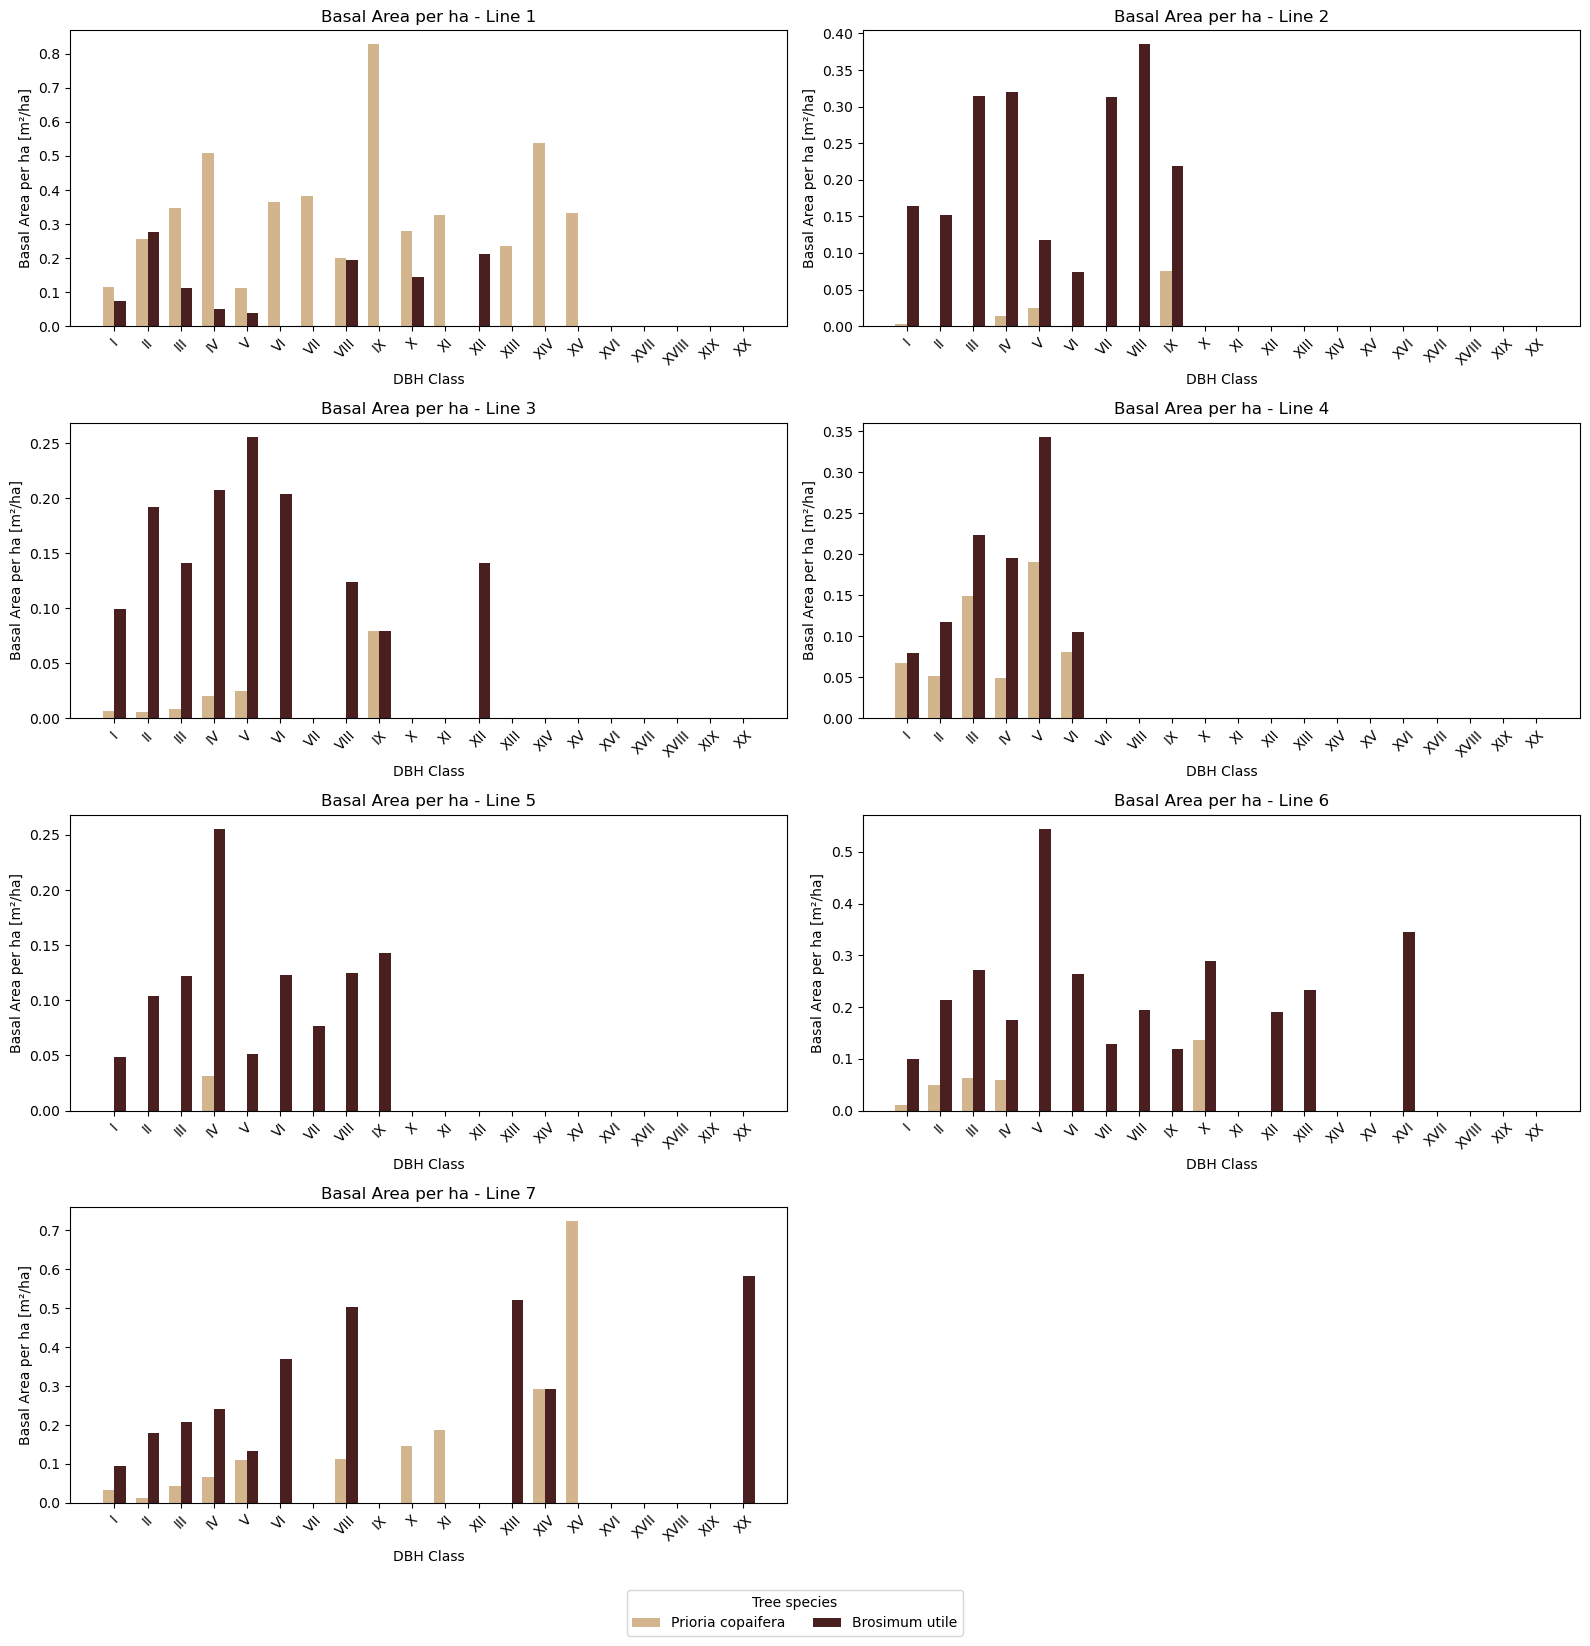

In [9]:
# Create a 4x2 matrix of subplots for Basal Area per ha by DBH Class for each line number
# Side-by-side bars per species
species_order = ['Prioria copaifera', 'Brosimum utile']
color_map = {
    'Brosimum utile': '#491f1f',
    'Prioria copaifera': '#D3B58D'
}

fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

# Ensure plot area and counts exist; fall back to defaults if not
try:
    plot_size_ha
except NameError:
    plot_size = 5000
    plot_size_ha = plot_size / 10000

plot_counts = df.groupby('Line Number')['Plot'].nunique()
line_area_ha = plot_counts * plot_size_ha

# determine ordered DBH Class categories
if hasattr(df["DBH Class"], "cat"):
    dbh_categories = list(df["DBH Class"].cat.categories)
else:
    dbh_categories = sorted(df["DBH Class"].unique())

width = 0.35

for i, line_num in enumerate(range(1, 8)):
    line_data = species_df[species_df["Line Number"] == line_num]

    # Basal area summed by DBH Class and Scientific name
    ba = (
        line_data
        .groupby(["DBH Class", "Scientific name"])['Basal area [m2]']
        .sum()
        .unstack(fill_value=0)
    )

    # ensure both species are present and in the specified order
    for s in species_order:
        if s not in ba.columns:
            ba[s] = 0
    ba = ba[species_order]

    # ensure all DBH categories are present
    ba = ba.reindex(index=dbh_categories, fill_value=0)

    # compute per-hectare basal area
    area = line_area_ha.get(line_num, np.nan)
    if area and area > 0:
        ba_per_ha = ba / area
    else:
        ba_per_ha = ba * np.nan

    x = np.arange(len(ba_per_ha))

    for j, species in enumerate(species_order):
        offsets = (j - (len(species_order) - 1)/2) * width
        axes[i].bar(x + offsets, ba_per_ha[species].values, width, label=species if i == 0 else "", color=color_map.get(species))

    axes[i].set_xlabel('DBH Class')
    axes[i].set_ylabel('Basal Area per ha [m²/ha]')
    axes[i].set_title(f'Basal Area per ha - Line {line_num}')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(ba_per_ha.index, rotation=45)

# Place a single horizontal legend centered below all subplots with a title
legend = fig.legend(ncol=len(species_order), loc='lower center', bbox_to_anchor=(0.5, -0.03), frameon=True, title='Tree species')
legend.get_title().set_fontsize('medium')
try:
    legend._legend_box.align = "center"
except Exception:
    pass

# Hide the last empty subplot
axes[7].set_visible(False)

# Adjust layout to make room for the legend
plt.tight_layout(rect=[0, 0.01, 1, 1])
plt.show()


### 3.2 Volume distribution

C:\Users\migue\AppData\Local\Temp\ipykernel_13512\3164670611.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["DBH Class", "Scientific name"])["Volume [m3]"].sum()
C:\Users\migue\AppData\Local\Temp\ipykernel_13512\3164670611.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["DBH Class", "Scientific name"])["Volume [m3]"].sum()
C:\Users\migue\AppData\Local\Temp\ipykernel_13512\3164670611.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt t

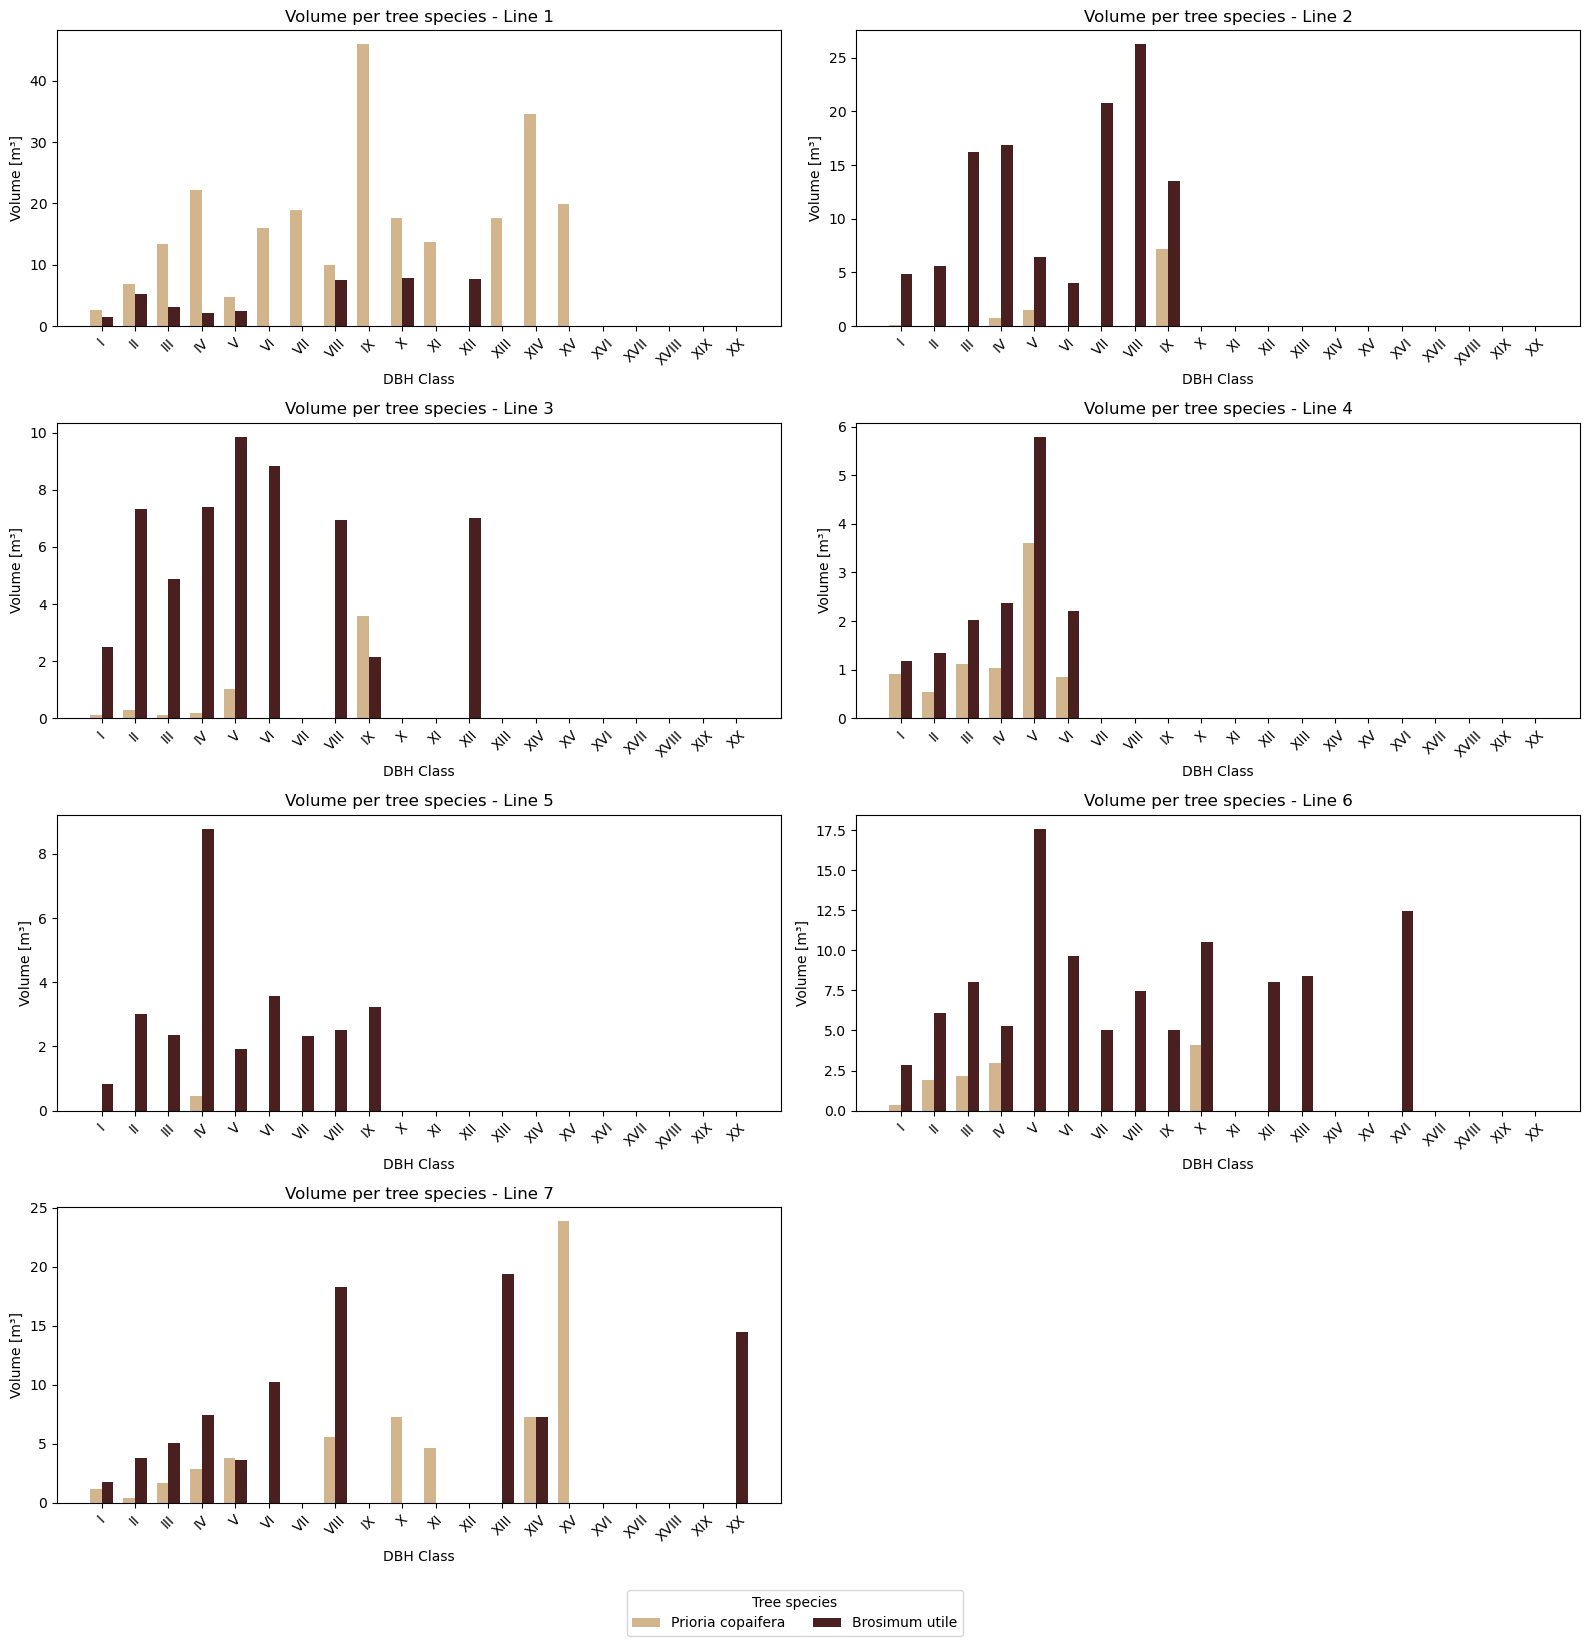

In [10]:
# Side-by-side Basal Area by DBH Class for Prioria copaifera and Brosimum utile
species_order = ['Prioria copaifera', 'Brosimum utile']
color_map = {
    'Brosimum utile': "#491f1f",
    'Prioria copaifera': "#D3B58D"
}

fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

# determine ordered DBH Class categories
if hasattr(species_df["DBH Class"], "cat"):
    dbh_categories = list(species_df["DBH Class"].cat.categories)
else:
    dbh_categories = sorted(species_df["DBH Class"].unique())

width = 0.35

for i, line_num in enumerate(range(1, 8)):
    line_data = species_df.loc[species_df["Line Number"] == line_num]
    # Basal area summed by DBH Class and Scientific name
    ba = (
        line_data
        .groupby(["DBH Class", "Scientific name"])["Volume [m3]"].sum()
        .unstack(fill_value=0)
    )

    # ensure both species are present in the columns and in the specified order
    for s in species_order:
        if s not in ba.columns:
            ba[s] = 0
    ba = ba[species_order]

    # ensure all DBH categories are present
    ba = ba.reindex(index=dbh_categories, fill_value=0)

    x = np.arange(len(ba))

    for j, species in enumerate(species_order):
        offsets = (j - (len(species_order) - 1)/2) * width
        axes[i].bar(x + offsets, ba[species].values, width, label=species if i == 0 else "", color=color_map.get(species))

    axes[i].set_xlabel('DBH Class')
    axes[i].set_ylabel('Volume [m³]')
    axes[i].set_title(f'Volume per tree species - Line {line_num}')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(ba.index, rotation=45)

# Place a single horizontal legend centered below all subplots with a title
legend = fig.legend(ncol=len(species_order), loc='lower center', bbox_to_anchor=(0.5, -0.03), frameon=True, title='Tree species')
legend.get_title().set_fontsize('medium')
try:
    legend._legend_box.align = "center"
except Exception:
    pass

# Hide the last empty subplot
axes[7].set_visible(False)

# Adjust layout to make room for the legend (reduced bottom space)
plt.tight_layout(rect=[0, 0.01, 1, 1])
plt.show()


C:\Users\migue\AppData\Local\Temp\ipykernel_13512\212846069.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_counts = df.groupby('Line Number')['Plot'].nunique()
C:\Users\migue\AppData\Local\Temp\ipykernel_13512\212846069.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["DBH Class", "Scientific name"])['Volume [m3]']
C:\Users\migue\AppData\Local\Temp\ipykernel_13512\212846069.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future defau

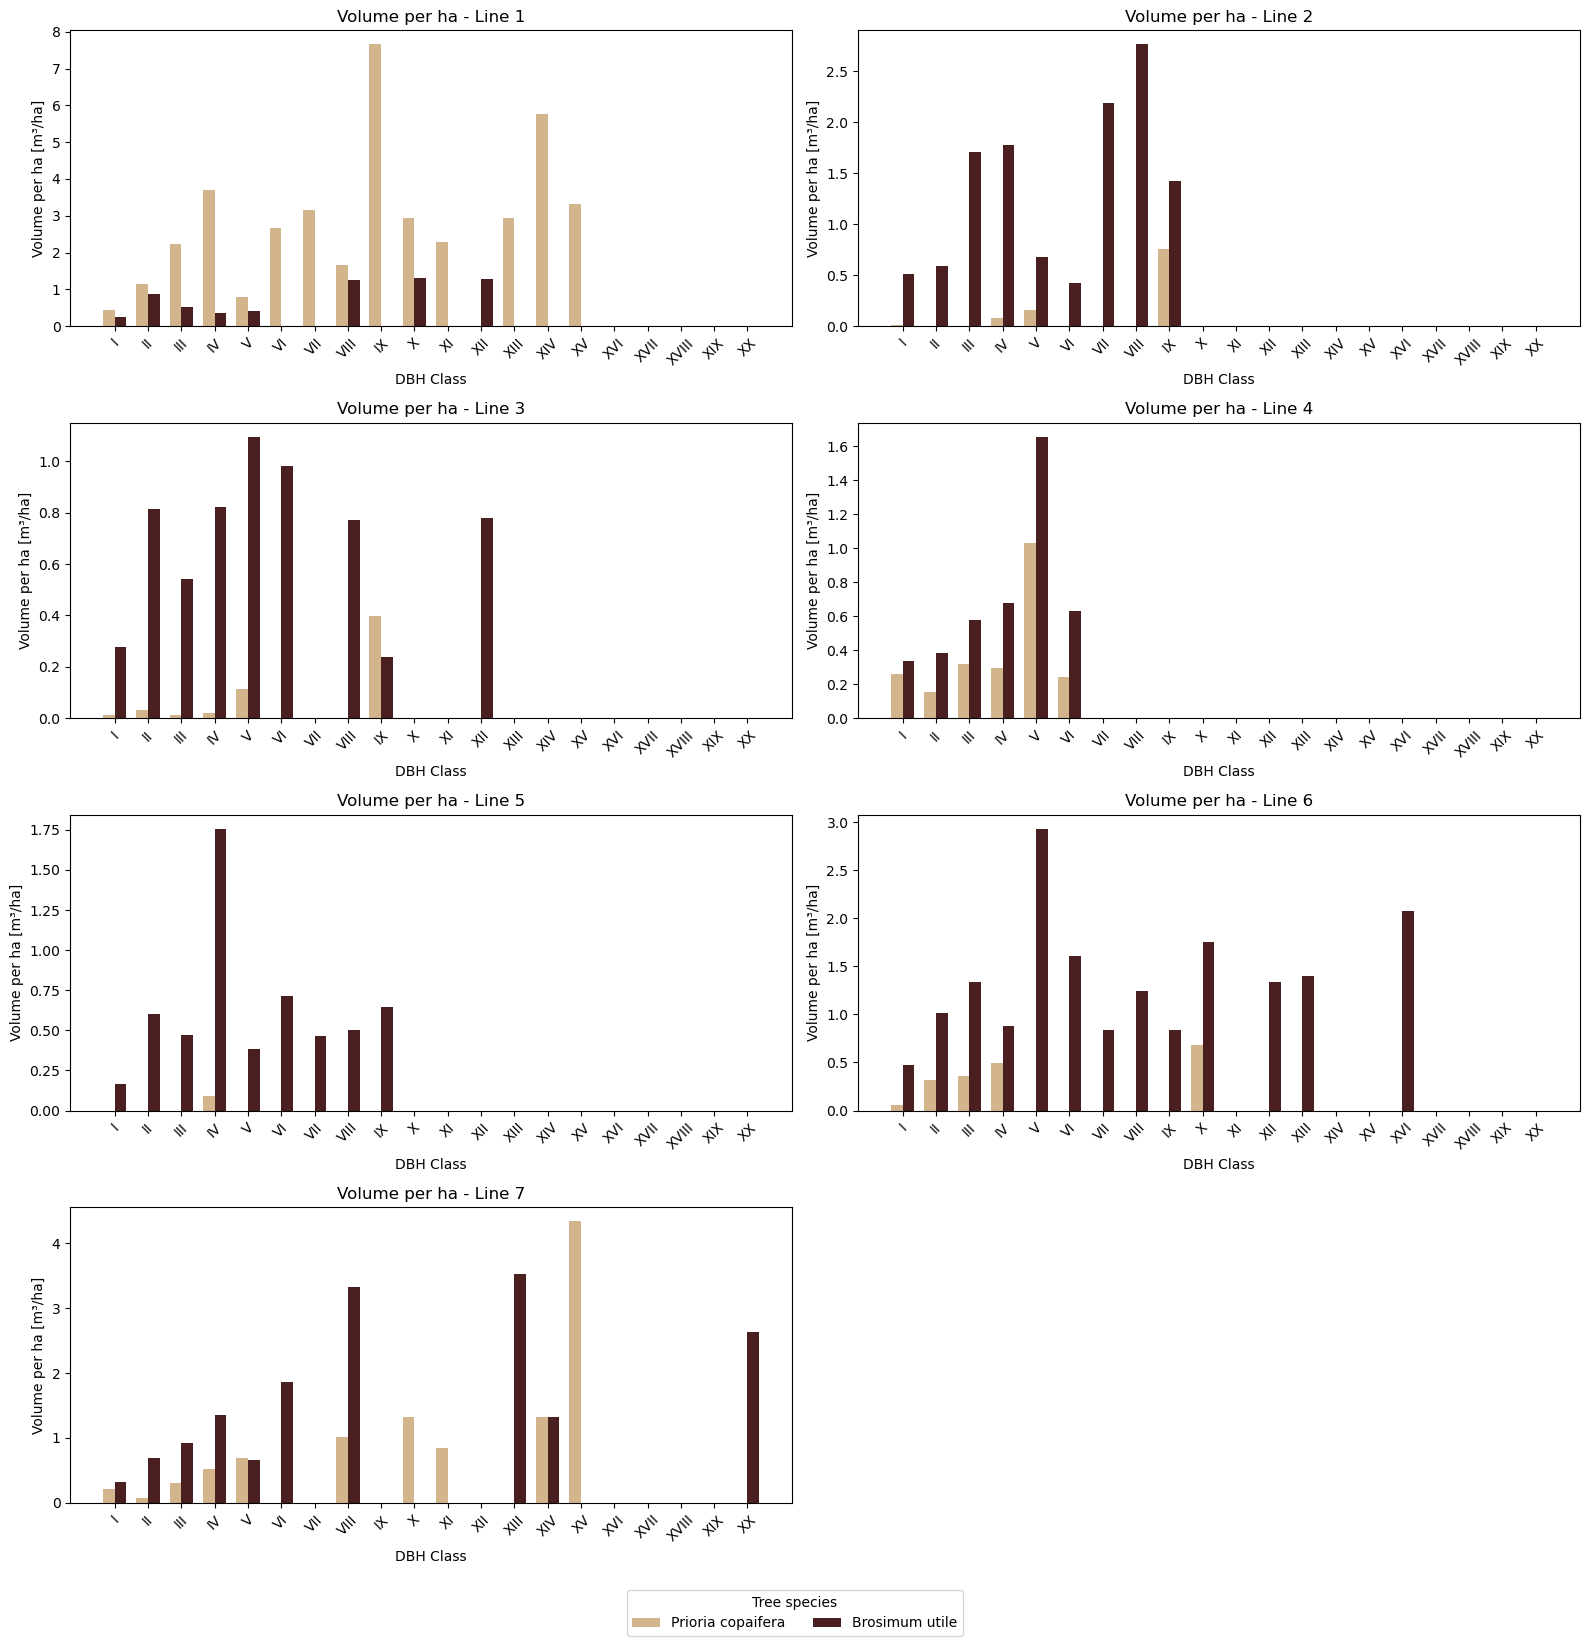

In [11]:
# Create a 4x2 matrix of subplots for Basal Area per ha by DBH Class for each line number
# Side-by-side bars per species
species_order = ['Prioria copaifera', 'Brosimum utile']
color_map = {
    'Brosimum utile': '#491f1f',
    'Prioria copaifera': '#D3B58D'
}

fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

# Ensure plot area and counts exist; fall back to defaults if not
try:
    plot_size_ha
except NameError:
    plot_size = 5000
    plot_size_ha = plot_size / 10000

plot_counts = df.groupby('Line Number')['Plot'].nunique()
line_area_ha = plot_counts * plot_size_ha

# determine ordered DBH Class categories
if hasattr(df["DBH Class"], "cat"):
    dbh_categories = list(df["DBH Class"].cat.categories)
else:
    dbh_categories = sorted(df["DBH Class"].unique())

width = 0.35

for i, line_num in enumerate(range(1, 8)):
    line_data = species_df[species_df["Line Number"] == line_num]

    # Basal area summed by DBH Class and Scientific name
    ba = (
        line_data
        .groupby(["DBH Class", "Scientific name"])['Volume [m3]']
        .sum()
        .unstack(fill_value=0)
    )

    # ensure both species are present and in the specified order
    for s in species_order:
        if s not in ba.columns:
            ba[s] = 0
    ba = ba[species_order]

    # ensure all DBH categories are present
    ba = ba.reindex(index=dbh_categories, fill_value=0)

    # compute per-hectare basal area
    area = line_area_ha.get(line_num, np.nan)
    if area and area > 0:
        ba_per_ha = ba / area
    else:
        ba_per_ha = ba * np.nan

    x = np.arange(len(ba_per_ha))

    for j, species in enumerate(species_order):
        offsets = (j - (len(species_order) - 1)/2) * width
        axes[i].bar(x + offsets, ba_per_ha[species].values, width, label=species if i == 0 else "", color=color_map.get(species))

    axes[i].set_xlabel('DBH Class')
    axes[i].set_ylabel('Volume per ha [m³/ha]')
    axes[i].set_title(f'Volume per ha - Line {line_num}')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(ba_per_ha.index, rotation=45)

# Place a single horizontal legend centered below all subplots with a title
legend = fig.legend(ncol=len(species_order), loc='lower center', bbox_to_anchor=(0.5, -0.03), frameon=True, title='Tree species')
legend.get_title().set_fontsize('medium')
try:
    legend._legend_box.align = "center"
except Exception:
    pass

# Hide the last empty subplot
axes[7].set_visible(False)

# Adjust layout to make room for the legend
plt.tight_layout(rect=[0, 0.01, 1, 1])
plt.show()


In [12]:
# Sum basal area by line and only for the two target species, then convert to per-hectare using line_area_ha
species_interest = ['Brosimum utile', 'Prioria copaifera']
basal_area_sum = (
    species_df[species_df['Scientific name'].isin(species_interest)]
    .groupby(['Line Number', 'Scientific name'])['Basal area [m2]']
    .sum()
    .unstack(fill_value=0)
)

# Convert to per-hectare
basal_area_ha_by_line = basal_area_sum.div(line_area_ha, axis=0)

# Keep specified species order and lines order (if available), then round
basal_area_ha_by_line = basal_area_ha_by_line.reindex(columns=species_interest, fill_value=0)
try:
    basal_area_ha_by_line = basal_area_ha_by_line.reindex(lines)
except NameError:
    pass

basal_area_ha_by_line = basal_area_ha_by_line.round(3)

# Display the result
print('Basal area (m²/ha) by Line and Species:')
display(basal_area_ha_by_line)


Basal area (m²/ha) by Line and Species:


C:\Users\migue\AppData\Local\Temp\ipykernel_13512\3658066777.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Line Number', 'Scientific name'])['Basal area [m2]']


Scientific name,Brosimum utile,Prioria copaifera
Line Number,,
1,1.101,4.822
2,2.059,0.117
3,1.445,0.145
4,1.065,0.589
5,1.049,0.031
6,3.071,0.319
7,3.127,1.729


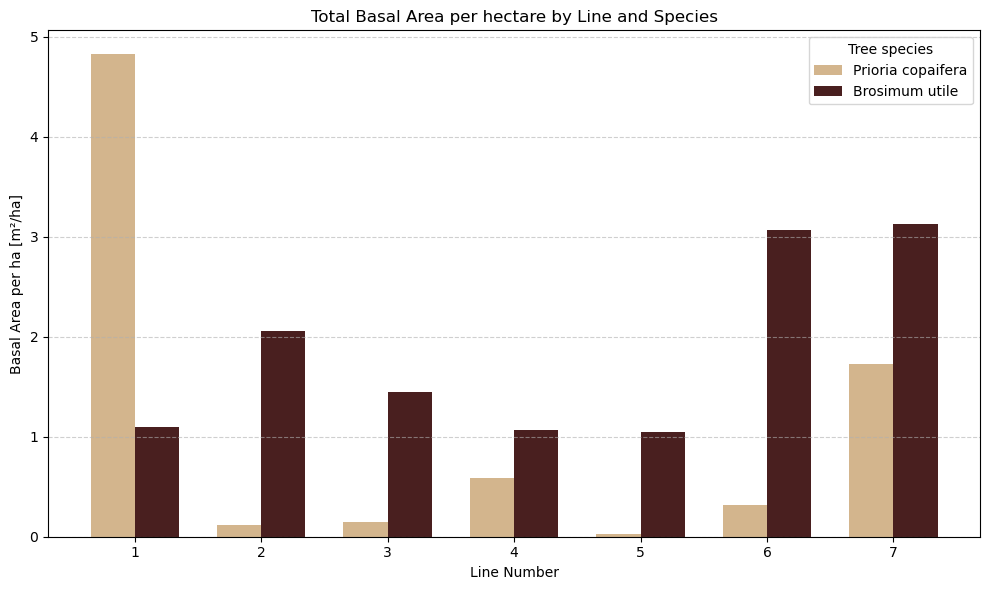

In [13]:
# Check if you accidentally did this:
import lines 

# It should be:
lines = [1, 2, 3, 4, 5, 6, 7] # Or whatever your line IDs are

species_order = ['Prioria copaifera', 'Brosimum utile']
color_map = {
    'Brosimum utile': '#491f1f',
    'Prioria copaifera': '#D3B58D'
}

fig, ax = plt.subplots(figsize=(10, 6))
width = 0.35
x = np.arange(len(basal_area_ha_by_line))
for j, species in enumerate(species_order):
    offsets = (j - (len(species_order) - 1)/2) * width
    ax.bar(x + offsets, basal_area_ha_by_line[species].values, width, label=species, color=color_map.get(species))
ax.set_xlabel('Line Number')
ax.set_ylabel('Basal Area per ha [m²/ha]')
ax.set_title('Total Basal Area per hectare by Line and Species')
ax.set_xticks(x)
ax.set_xticklabels(basal_area_ha_by_line.index.astype(str))
ax.legend(title='Tree species')
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [14]:
# Check if you accidentally did this:
import lines 

# It should be:
lines = [1, 2, 3, 4,5, 6, 7] # Or whatever your line IDs are

# Sum volume by line for target species, then convert to per-hectare
species_interest = ['Brosimum utile', 'Prioria copaifera']
volume_sum = (
    species_df[species_df['Scientific name'].isin(species_interest)]
    .groupby(['Line Number', 'Scientific name'])['Volume [m3]']
    .sum()
    .unstack(fill_value=0)
)

# Convert to per-hectare
volume_ha_by_line = volume_sum.div(line_area_ha, axis=0)

# Maintain species and line order, then round
volume_ha_by_line = volume_ha_by_line.reindex(columns=species_interest, fill_value=0)
try:
    volume_ha_by_line = volume_ha_by_line.reindex(lines)
except NameError:
    pass

volume_ha_by_line = volume_ha_by_line.round(3)

# Display the result
print('Volume (m³/ha) by Line and Species:')
display(volume_ha_by_line)

Volume (m³/ha) by Line and Species:


C:\Users\migue\AppData\Local\Temp\ipykernel_13512\397381541.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Line Number', 'Scientific name'])['Volume [m3]']


Scientific name,Brosimum utile,Prioria copaifera
Line Number,,
1,6.224,40.665
2,12.048,1.002
3,6.316,0.589
4,4.262,2.305
5,5.698,0.094
6,17.734,1.907
7,16.623,10.633


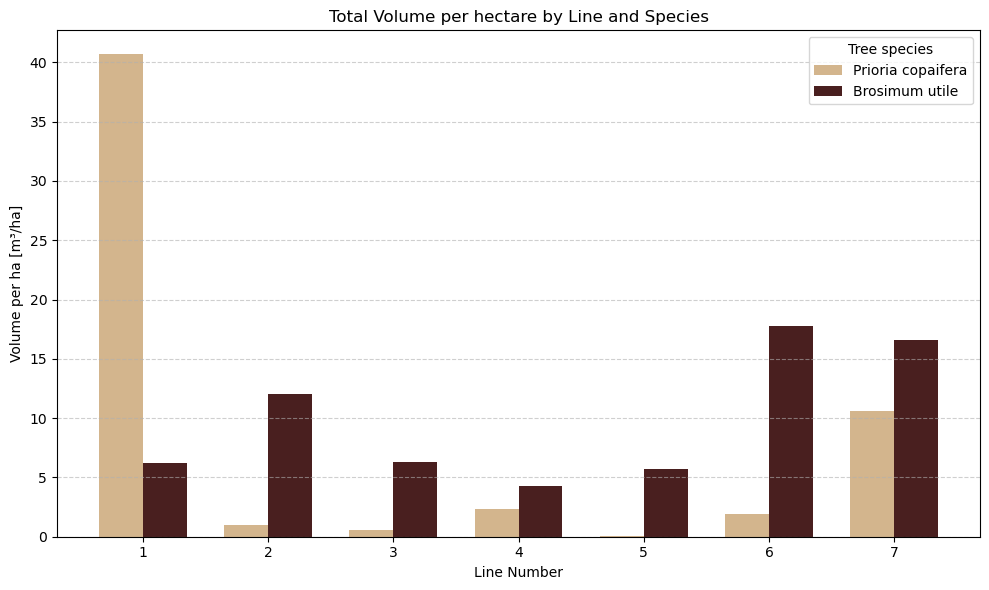

In [15]:
# Check if you accidentally did this:
import lines 

# It should be:
lines = [1, 2, 3, 4,5, 6, 7] # Or whatever your line IDs are

species_order = ['Prioria copaifera', 'Brosimum utile']
color_map = {
    'Brosimum utile': '#491f1f',
    'Prioria copaifera': '#D3B58D'
}

fig, ax = plt.subplots(figsize=(10, 6))
width = 0.35
x = np.arange(len(volume_ha_by_line))
for j, species in enumerate(species_order):
    offsets = (j - (len(species_order) - 1)/2) * width
    ax.bar(x + offsets, volume_ha_by_line[species].values, width, label=species, color=color_map.get(species))
ax.set_xlabel('Line Number')
ax.set_ylabel('Volume per ha [m³/ha]')
ax.set_title('Total Volume per hectare by Line and Species')
ax.set_xticks(x)
ax.set_xticklabels(volume_ha_by_line.index.astype(str))
ax.legend(title='Tree species')
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()